# 피처 엔지니어링 — 가설1: 배송 지연 피처

**목표**: cutoff 기준 시간 분리를 엄격히 준수하여 배송 지연 관련 피처를 생성하고 레이블을 부여한 최종 피처 테이블을 만듭니다.

**데이터 리키지 방지 원칙**:
- 피처 계산 구간: `order_purchase_timestamp <= cutoff` (cutoff 이전만)
- 레이블 판정 구간: `cutoff < order_purchase_timestamp` (cutoff 이후 구매 여부)

---
## 1. 라이브러리 & 데이터 로드

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')
sns.set_theme(font_scale=1.5)

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

os.makedirs('../data/interim', exist_ok=True)
os.makedirs('../outputs', exist_ok=True)

# 원본 데이터 로드
orders = pd.read_csv('../data/raw/olist_orders_dataset.csv', parse_dates=[
    'order_purchase_timestamp',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
])
customers = pd.read_csv('../data/raw/olist_customers_dataset.csv')

print("로드 완료")
print(f"  orders   : {orders.shape}")
print(f"  customers: {customers.shape}")

로드 완료
  orders   : (99441, 8)
  customers: (99441, 5)


---
## 2. cutoff 설정 및 시간 기반 분리

> **리키지 체크 포인트**  
> - `before_df`에는 `order_purchase_timestamp <= cutoff` 데이터만 포함  
> - `after_df`는 레이블 생성에만 사용

In [2]:
# cutoff = 전체 주문 최대 날짜 - 90일
cutoff = orders['order_purchase_timestamp'].max() - pd.Timedelta(days=90)
print(f"전체 주문 기간: {orders['order_purchase_timestamp'].min().date()} ~ {orders['order_purchase_timestamp'].max().date()}")
print(f"cutoff        : {cutoff.date()}")

# customer_unique_id 매핑을 위해 customers 병합
orders_merged = orders.merge(customers[['customer_id', 'customer_unique_id']], on='customer_id')

# ── 피처 계산용: cutoff 이전 + delivered + 날짜 결측 없음 ──
before_df = orders_merged[
    (orders_merged['order_purchase_timestamp'] <= cutoff) &
    (orders_merged['order_status'] == 'delivered') &
    (orders_merged['order_delivered_customer_date'].notna()) &
    (orders_merged['order_estimated_delivery_date'].notna())
].copy()

# ── 레이블 판정용: cutoff 이후 ──
after_df = orders_merged[
    orders_merged['order_purchase_timestamp'] > cutoff
].copy()

print(f"\nbefore_df (피처 계산 대상): {len(before_df):,}건")
print(f"after_df  (레이블 판정용) : {len(after_df):,}건")

전체 주문 기간: 2016-09-04 ~ 2018-10-17
cutoff        : 2018-07-19

before_df (피처 계산 대상): 87,186건
after_df  (레이블 판정용) : 9,529건


---
## 3. 레이블 생성

- `label = 1` (이탈): cutoff 이전에 구매한 고객 중 cutoff 이후 재구매 없음  
- `label = 0` (유지): cutoff 이후 재구매 있음

In [3]:
# 피처 계산 대상 고객 (cutoff 이전 구매 고객 전체)
all_customers_uid = before_df['customer_unique_id'].unique()

# cutoff 이후 재구매한 고객 집합 (유지 고객)
retained_set = set(after_df['customer_unique_id'].unique())

# 레이블 DataFrame 생성
labels = pd.DataFrame({'customer_unique_id': all_customers_uid})
labels['label'] = labels['customer_unique_id'].apply(
    lambda x: 0 if x in retained_set else 1  # 1=이탈, 0=유지
)

label_dist = labels['label'].value_counts()
label_ratio = labels['label'].value_counts(normalize=True)

print("=== 레이블 분포 ===")
print(f"  유지 (label=0): {label_dist[0]:,}명 ({label_ratio[0]:.1%})")
print(f"  이탈 (label=1): {label_dist[1]:,}명 ({label_ratio[1]:.1%})")
print(f"  전체 고객 수  : {len(labels):,}명")

=== 레이블 분포 ===
  유지 (label=0): 232명 (0.3%)
  이탈 (label=1): 84,139명 (99.7%)
  전체 고객 수  : 84,371명


---
## 4. 가설1 피처 계산 — 배송 지연

> `before_df`만 사용, cutoff 이후 데이터는 포함하지 않습니다.

In [4]:
def calc_delivery_features(before_df: pd.DataFrame, cutoff: pd.Timestamp) -> pd.DataFrame:
    df = before_df.copy()

    df['delivery_delay_days'] = (
        df['order_delivered_customer_date'] -
        df['order_estimated_delivery_date']
    ).dt.days

    feat = df.groupby('customer_unique_id').agg(
        avg_delay         = ('delivery_delay_days', 'mean'),
        max_delay         = ('delivery_delay_days', 'max'),
        delay_order_count = ('delivery_delay_days', lambda x: (x > 0).sum()),
        total_orders      = ('order_id', 'nunique'),
        last_order_ts     = ('order_purchase_timestamp', 'max'),
    ).reset_index()

    feat['delay_rate']      = feat['delay_order_count'] / feat['total_orders']
    feat['is_ever_delayed'] = (feat['delay_order_count'] > 0).astype(int)
    feat['recency_days']    = (cutoff - feat['last_order_ts']).dt.days
    feat = feat.drop(columns=['last_order_ts'])

    # pandas Nullable Extension Type → numpy dtype 변환 (pyarrow 호환)
    for col in feat.columns:
        if hasattr(feat[col].dtype, 'numpy_dtype'):
            feat[col] = feat[col].astype(feat[col].dtype.numpy_dtype)

    return feat


feat_delay = calc_delivery_features(before_df, cutoff)

print(f"배송 지연 피처 생성 완료: {feat_delay.shape}")
print("\n=== 피처 기술 통계 ===")
print(feat_delay[['avg_delay', 'max_delay', 'delay_rate', 'is_ever_delayed', 'recency_days']].describe().round(3))

배송 지연 피처 생성 완료: (84371, 8)

=== 피처 기술 통계 ===
       avg_delay  max_delay  delay_rate  is_ever_delayed  recency_days
count  84371.000  84371.000   84371.000        84371.000     84371.000
mean     -12.175    -12.047       0.070            0.071       219.487
std       10.307     10.356       0.253            0.257       142.187
min     -147.000   -147.000       0.000            0.000         0.000
25%      -17.000    -17.000       0.000            0.000       103.000
50%      -13.000    -13.000       0.000            0.000       197.000
75%       -8.000     -8.000       0.000            0.000       322.000
max      188.000    188.000       1.000            1.000       672.000


---
## 5. 피처 테이블 병합 (labels + 가설1 피처)

In [5]:
# labels와 피처 병합 (left join: 레이블 기준)
features = labels.merge(feat_delay, on='customer_unique_id', how='left')

print(f"피처 테이블 shape: {features.shape}")
print(f"컬럼 목록: {features.columns.tolist()}")

피처 테이블 shape: (84371, 9)
컬럼 목록: ['customer_unique_id', 'label', 'avg_delay', 'max_delay', 'delay_order_count', 'total_orders', 'delay_rate', 'is_ever_delayed', 'recency_days']


---
## 6. 결측치 확인

In [6]:
null_counts = features.isnull().sum()
null_pct    = features.isnull().mean() * 100

null_report = pd.DataFrame({
    'null_count': null_counts,
    'null_pct(%)': null_pct.round(2)
})
print(null_report)

total_nulls = null_counts.sum()
print(f"\n전체 결측치 수: {total_nulls}")

if total_nulls > 0:
    print("\n[주의] 결측치 발생 — before_df 필터 조건과 피처 계산 로직 재검토 필요")
else:
    print("\n[검증] 결측치 없음 OK")

                    null_count  null_pct(%)
customer_unique_id           0          0.0
label                        0          0.0
avg_delay                    0          0.0
max_delay                    0          0.0
delay_order_count            0          0.0
total_orders                 0          0.0
delay_rate                   0          0.0
is_ever_delayed              0          0.0
recency_days                 0          0.0

전체 결측치 수: 0

[검증] 결측치 없음 OK


---
## 7. 레이블 분포 재확인

In [7]:
print("=== 최종 피처 테이블 레이블 분포 ===")
vc = features['label'].value_counts()
vr = features['label'].value_counts(normalize=True)
print(f"  유지 (label=0): {vc[0]:,}명 ({vr[0]:.1%})")
print(f"  이탈 (label=1): {vc[1]:,}명 ({vr[1]:.1%})")

=== 최종 피처 테이블 레이블 분포 ===
  유지 (label=0): 232명 (0.3%)
  이탈 (label=1): 84,139명 (99.7%)


---
## 8. SMOTE 오버샘플링 — 클래스 불균형 해소

> 원본 데이터는 이탈 99.7% : 유지 0.3% (약 362:1 불균형).  
> SMOTE로 유지(label=0) 합성 샘플을 생성해 1:1 균형 데이터셋 구성.  
> 모델 학습에는 `features_smote.parquet` 사용, 추론/해석에는 원본 `features.parquet` 사용.

In [8]:
from imblearn.over_sampling import SMOTE

feat_cols = [c for c in features.columns if c not in ['customer_unique_id', 'label']]
X = features[feat_cols].values
y = features['label'].values

print(f"SMOTE 전 │ label=0(유지): {(y==0).sum():,}  label=1(이탈): {(y==1).sum():,}")

sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X, y)

features_smote = pd.DataFrame(X_res, columns=feat_cols)
features_smote.insert(0, 'label', y_res)

print(f"SMOTE 후 │ label=0(유지): {(y_res==0).sum():,}  label=1(이탈): {(y_res==1).sum():,}")
print(f"\n피처 테이블 shape (SMOTE): {features_smote.shape}")
print(f"컬럼: {features_smote.columns.tolist()}")

SMOTE 전 │ label=0(유지): 232  label=1(이탈): 84,139
SMOTE 후 │ label=0(유지): 84,139  label=1(이탈): 84,139

피처 테이블 shape (SMOTE): (168278, 8)
컬럼: ['label', 'avg_delay', 'max_delay', 'delay_order_count', 'total_orders', 'delay_rate', 'is_ever_delayed', 'recency_days']


---
## 9. 피처 분포 시각화 (이탈/유지 그룹 비교)

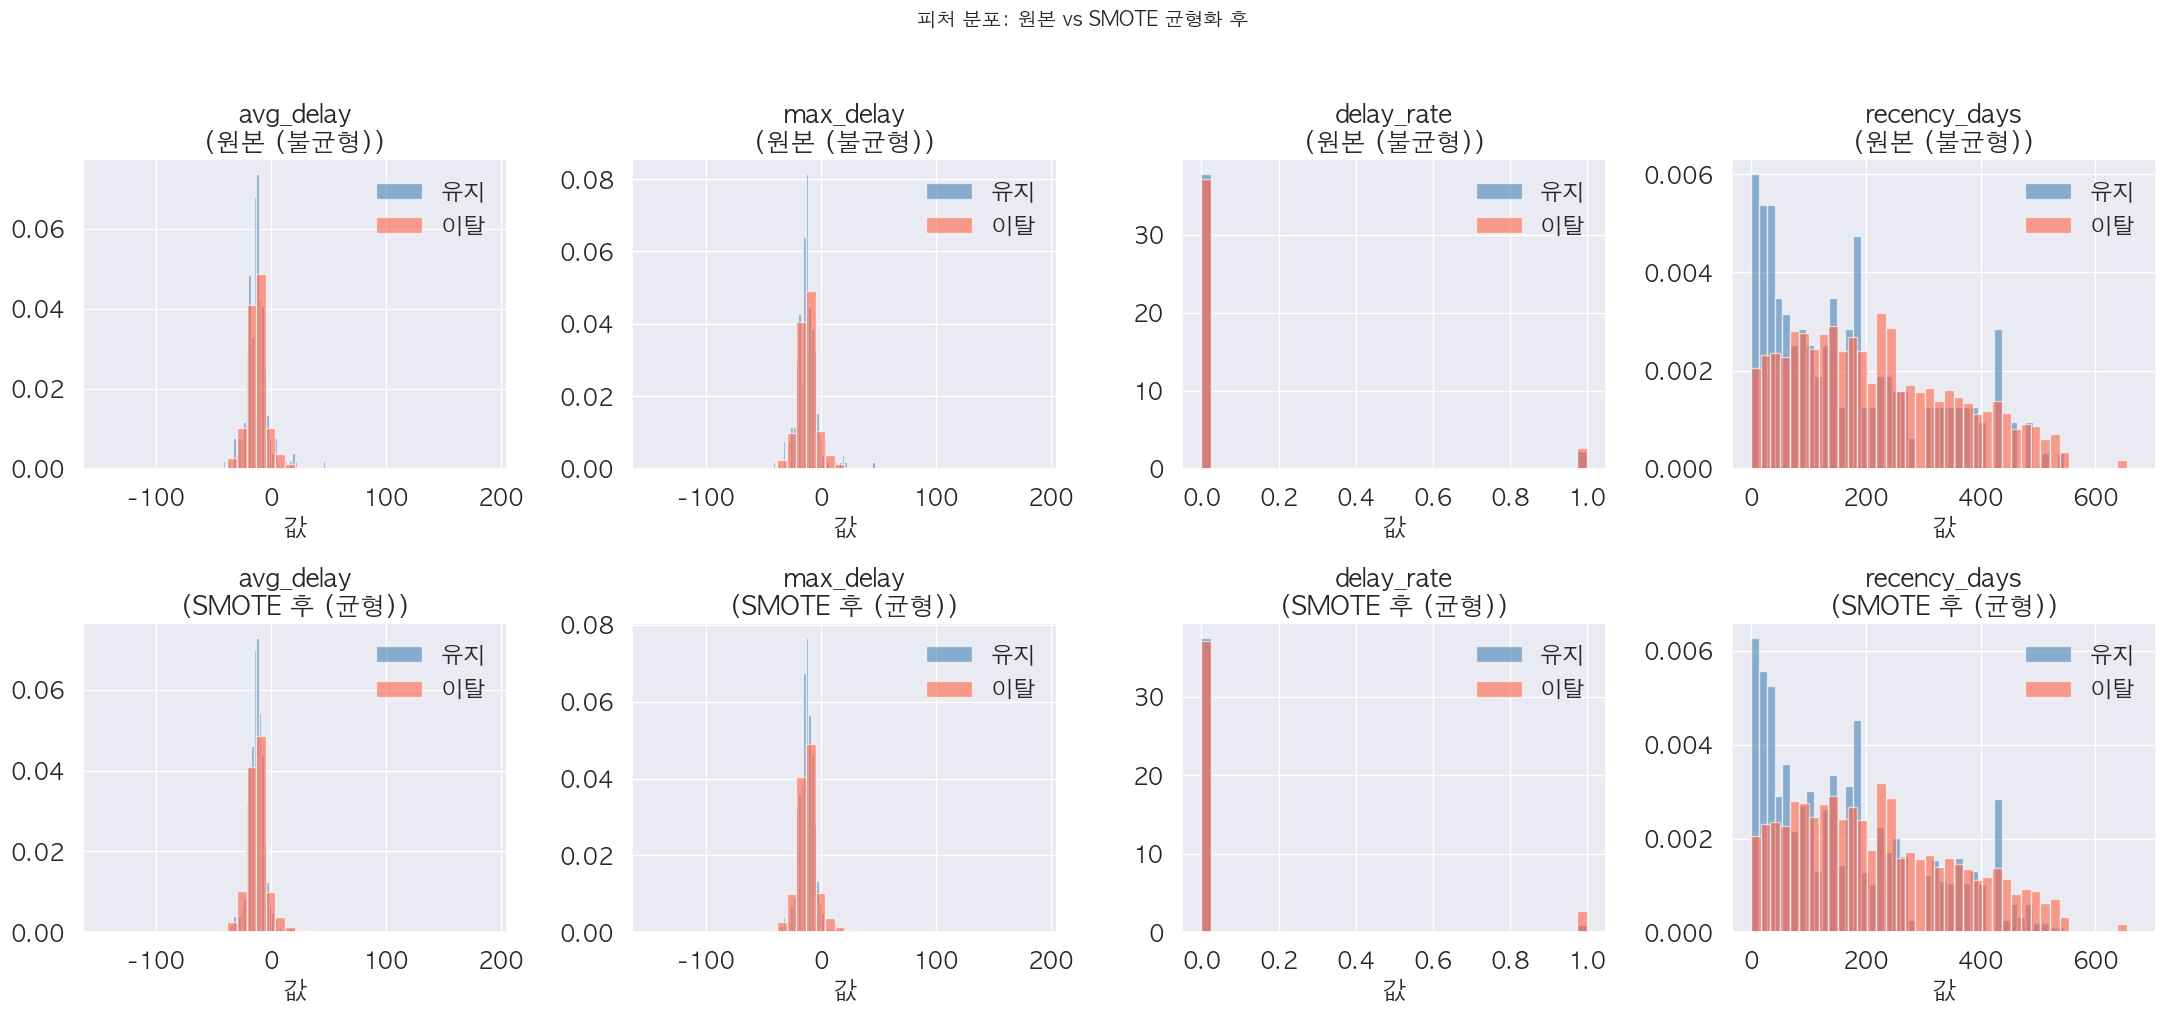

In [9]:
feat_cols_plot = ['avg_delay', 'max_delay', 'delay_rate', 'recency_days']
fig, axes = plt.subplots(2, 4, figsize=(22, 10))

for col_i, col in enumerate(feat_cols_plot):
    for row_i, (df_plot, title_suffix) in enumerate([
        (features,       '원본 (불균형)'),
        (features_smote, 'SMOTE 후 (균형)'),
    ]):
        ax = axes[row_i][col_i]
        for label_val, color, name in [(0, 'steelblue', '유지'), (1, 'tomato', '이탈')]:
            subset = df_plot[df_plot['label'] == label_val][col].dropna()
            ax.hist(subset, bins=40, alpha=0.6, color=color, label=name, density=True)
        ax.set_title(f'{col}\n({title_suffix})')
        ax.set_xlabel('값')
        ax.legend()

plt.suptitle('피처 분포: 원본 vs SMOTE 균형화 후', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/fe_h1_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. 중간 결과 저장 및 최종 피처 테이블 저장

In [10]:
# 중간 결과: 배송 지연 피처만 별도 저장 (원본, 불균형)
feat_delay_path = '../data/interim/feat_delivery.parquet'
feat_delay.to_parquet(feat_delay_path, index=False)
print(f"[저장] 중간 결과 (배송 지연 피처, 원본): {feat_delay_path}")

# 최종 피처 테이블: 원본 (추론/해석용)
features_path = '../data/interim/features.parquet'
features.to_parquet(features_path, index=False)
print(f"[저장] 최종 피처 테이블 (원본, 불균형): {features_path}")

# 최종 피처 테이블: SMOTE 균형화 (모델 학습용)
features_smote_path = '../data/interim/features_smote.parquet'
features_smote.to_parquet(features_smote_path, index=False)
print(f"[저장] 최종 피처 테이블 (SMOTE 균형화): {features_smote_path}")

print(f"\n=== 저장된 파일 요약 ===")
print(f"  원본     shape: {features.shape}  용량: {os.path.getsize(features_path)/1024:.1f} KB")
print(f"  SMOTE후  shape: {features_smote.shape}  용량: {os.path.getsize(features_smote_path)/1024:.1f} KB")

[저장] 중간 결과 (배송 지연 피처, 원본): ../data/interim/feat_delivery.parquet
[저장] 최종 피처 테이블 (원본, 불균형): ../data/interim/features.parquet
[저장] 최종 피처 테이블 (SMOTE 균형화): ../data/interim/features_smote.parquet

=== 저장된 파일 요약 ===
  원본     shape: (84371, 9)  용량: 3038.1 KB
  SMOTE후  shape: (168278, 8)  용량: 2978.7 KB


---
## 11. 검증 — 저장된 파일 재로드 확인

In [11]:
# 저장된 parquet 재로드하여 무결성 검증
df_orig_check  = pd.read_parquet('../data/interim/features.parquet')
df_smote_check = pd.read_parquet('../data/interim/features_smote.parquet')

print("=== 원본 피처 테이블 검증 ===")
print(f"  shape       : {df_orig_check.shape}")
print(f"  결측치 합계 : {df_orig_check.isnull().sum().sum()}")
print(f"  레이블 분포 : {df_orig_check['label'].value_counts().to_dict()}")

print("\n=== SMOTE 피처 테이블 검증 ===")
print(f"  shape       : {df_smote_check.shape}")
print(f"  결측치 합계 : {df_smote_check.isnull().sum().sum()}")
print(f"  레이블 분포 : {df_smote_check['label'].value_counts().to_dict()}")

smote_balanced = df_smote_check['label'].value_counts()
is_balanced = smote_balanced[0] == smote_balanced[1]

print("\n=== 최종 체크리스트 ===")
print(f"  [O] cutoff 이후 데이터가 피처에 포함되지 않음")
print(f"  [{'O' if 'customer_unique_id' in df_orig_check.columns else 'X'}] 원본 테이블: customer_unique_id 기준 그룹핑")
print(f"  [{'O' if 'recency_days' in df_orig_check.columns else 'X'}] recency_days 피처 포함")
print(f"  [{'O' if is_balanced else 'X'}] SMOTE 테이블: 클래스 균형 (label=0:1 = 1:1)")
print(f"  [{'O' if df_orig_check['label'].isin([0, 1]).all() else 'X'}] label 값이 0 또는 1만 존재")

=== 원본 피처 테이블 검증 ===
  shape       : (84371, 9)
  결측치 합계 : 0
  레이블 분포 : {1: 84139, 0: 232}

=== SMOTE 피처 테이블 검증 ===
  shape       : (168278, 8)
  결측치 합계 : 0
  레이블 분포 : {1: 84139, 0: 84139}

=== 최종 체크리스트 ===
  [O] cutoff 이후 데이터가 피처에 포함되지 않음
  [O] 원본 테이블: customer_unique_id 기준 그룹핑
  [O] recency_days 피처 포함
  [O] SMOTE 테이블: 클래스 균형 (label=0:1 = 1:1)
  [O] label 값이 0 또는 1만 존재
